In [53]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
import pandas as pd


In [80]:
def extract_gaussian_fits(np_data,title,column_names):
    num_cols = np_data.shape[1]
    num_rows = int(np.ceil(num_cols / 6))  # Adjust the number of columns per row as needed
    
    fig, axs = plt.subplots(num_rows, 6, figsize=(18, 2*num_rows))  # Adjust the number of columns per row as needed
    gaussians = []

    for i in range(num_cols):
        row = i // 6  # Calculate the row index
        col = i % 6  # Calculate the column index
        axs[row, col].hist(np_data[:, i], bins=80, density=True)
        axs[row, col].set_title(f'{column_names[i]}')
        #fit and plot a gaussian mixture model with 2 components
        X = np_data[:, i].reshape(-1, 1)
        gm = GaussianMixture(n_components=2, random_state=0).fit(X)
        gaussians.append(gm)
        x = np.linspace(np.min(X), np.max(X), 1000)
        logprob = gm.score_samples(x.reshape(-1, 1))
        pdf = np.exp(logprob)
        axs[row, col].fill_between(x, pdf, alpha=0.5,color='r')
        axs[row, col].set_xlim(np.min(X), np.max(X))

        axs[row, col].set_xlabel('Value')
        axs[row, col].set_ylabel('Density')
        # print(f'Column {i} mu1={gm.means_[0]}, mu2={gm.means_[1]} sigma1={np.sqrt(gm.covariances_[0])}, sigma2={np.sqrt(gm.covariances_[1])} w1={gm.weights_[0]}, w2={gm.weights_[1]} n1={int(n * gm.weights_[0])} n2={int(n * gm.weights_[1])}')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    return gaussians

In [54]:
#load the data
data_path = "../../initialSingleCellDf-channel-20220916-MW_018-001.h5"
data = pd.read_hdf(data_path, key="df")
data

Marker                                               FSC-A  SSC-A  CD25  CD38  \
CellType Peptide Concentration Replicate Time Event                             
APCs     N4      1uM           1         4.0  1        771    143   314   259   
                                              2        345     49   260   278   
                                              3        387     82   355   199   
                                              4        379    120   277   241   
                                              5        313    174   313   253   
...                                                    ...    ...   ...   ...   
OT-1     null    10pM          2         72.0 8464     393    184   271   280   
                                              8465     316    108   286   327   
                                              8466     274    131   301   260   
                                              8467     357     91   295   295   
                                              8468     182    129   319   262   

Marker                                               Granzyme B  CD2  CD27  \
CellType Peptide Concentration Replicate Time Event                          
APCs     N4      1uM           1         4.0  1             445  209   337   
                                              2             395  239   273   
                                              3             512  192   298   
                                              4             411  282   274   
                                              5             414  254   280   
...                                                         ...  ...   ...   
OT-1     null    10pM          2         72.0 8464          287  212   288   
                                              8465          284   17   304   
                                              8466          315  447   279   
                                              8467          294  380   268   
                                              8468          278  426   302   

Marker                                               CD45RA  CD4  CD86  ...  \
CellType Peptide Concentration Replicate Time Event                     ...   
APCs     N4      1uM           1         4.0  1         482  227   277  ...   
                                              2         414  261   270  ...   
                                              3         369  225   292  ...   
                                              4         401  247   292  ...   
                                              5         336  260   290  ...   
...                                                     ...  ...   ...  ...   
OT-1     null    10pM          2         72.0 8464      298  246   294  ...   
                                              8465      379  260   304  ...   
                                              8466      278  270   315  ...   
                                              8467      263  253   279  ...   
                                              8468      265  289   277  ...   

Marker                                               CD126  Proliferation  \
CellType Peptide Concentration Replicate Time Event                         
APCs     N4      1uM           1         4.0  1        312            865   
                                              2        296            346   
                                              3        296            349   
                                              4        259            371   
                                              5        264            320   
...                                                    ...            ...   
OT-1     null    10pM          2         72.0 8464     338            621   
                                              8465     268            823   
                                              8466     295            809   
                                              8467     2

In [68]:
def get_subset_data(data,data_filters):
    return data.loc[(data.index.get_level_values('CellType') == data_filters['CellType']) & (data.index.get_level_values('Time') == data_filters['Time']) & (data.index.get_level_values('Peptide') == data_filters['Peptide']) & (data.index.get_level_values('Concentration') == data_filters['Concentration'])]

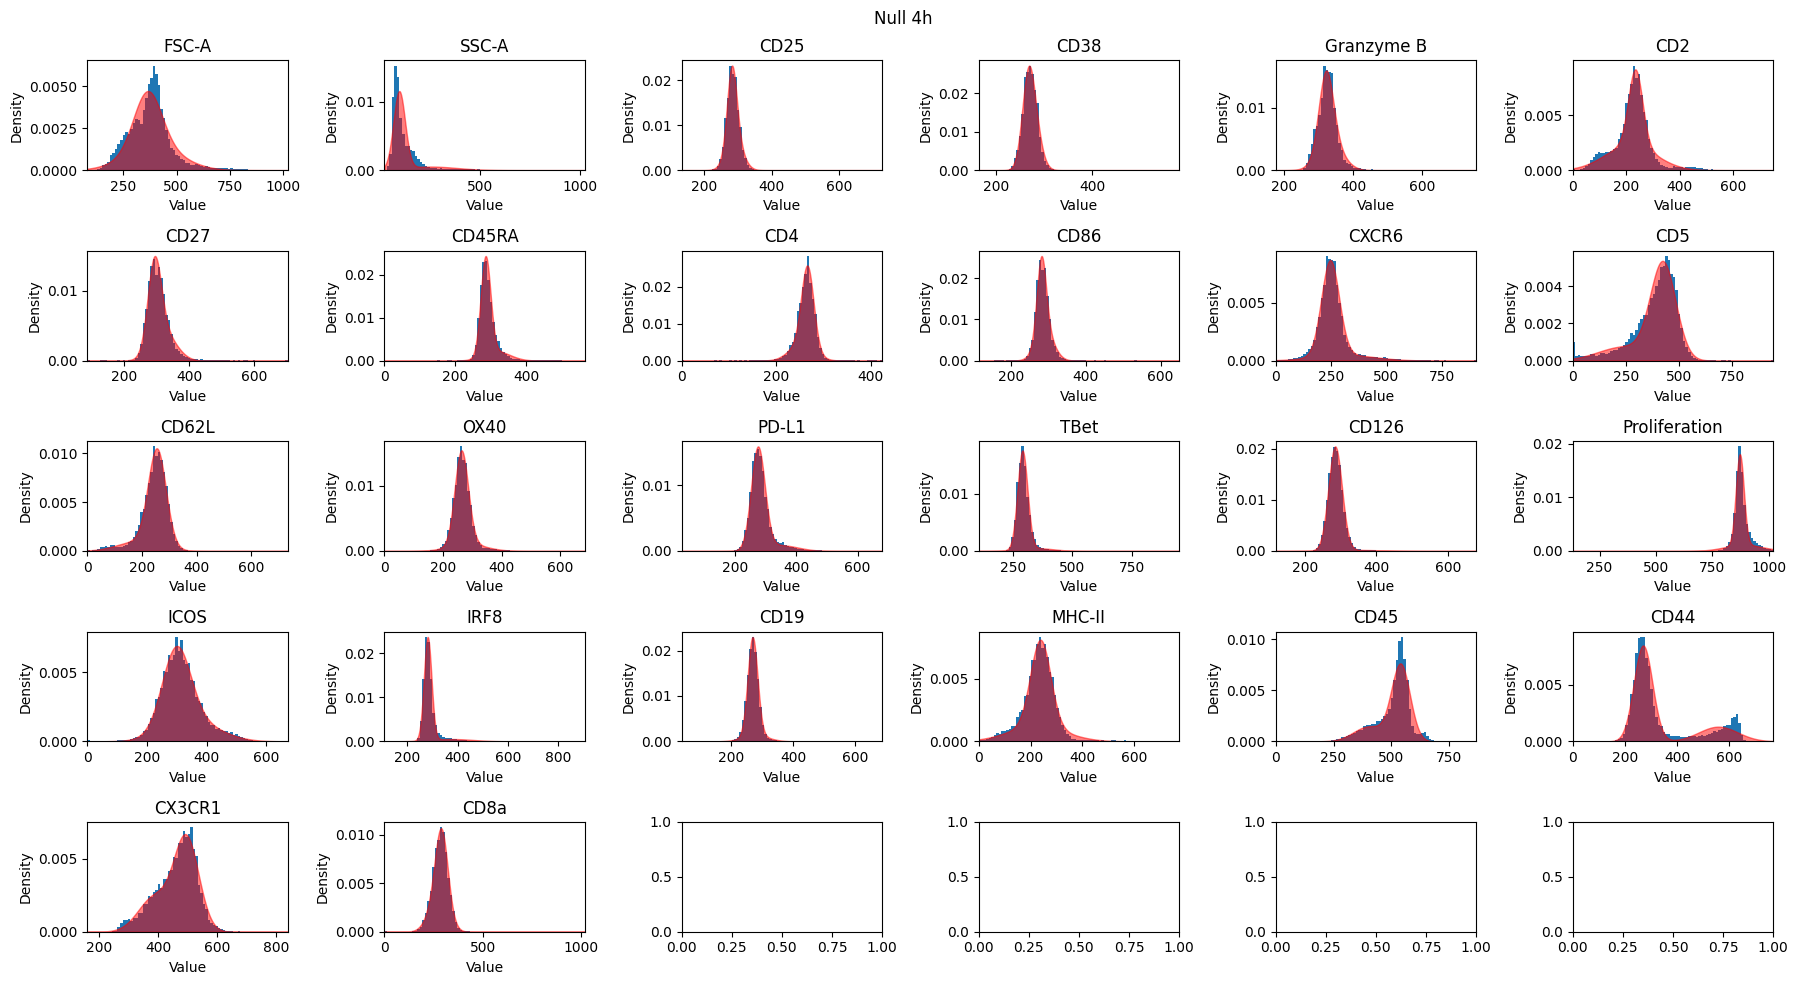

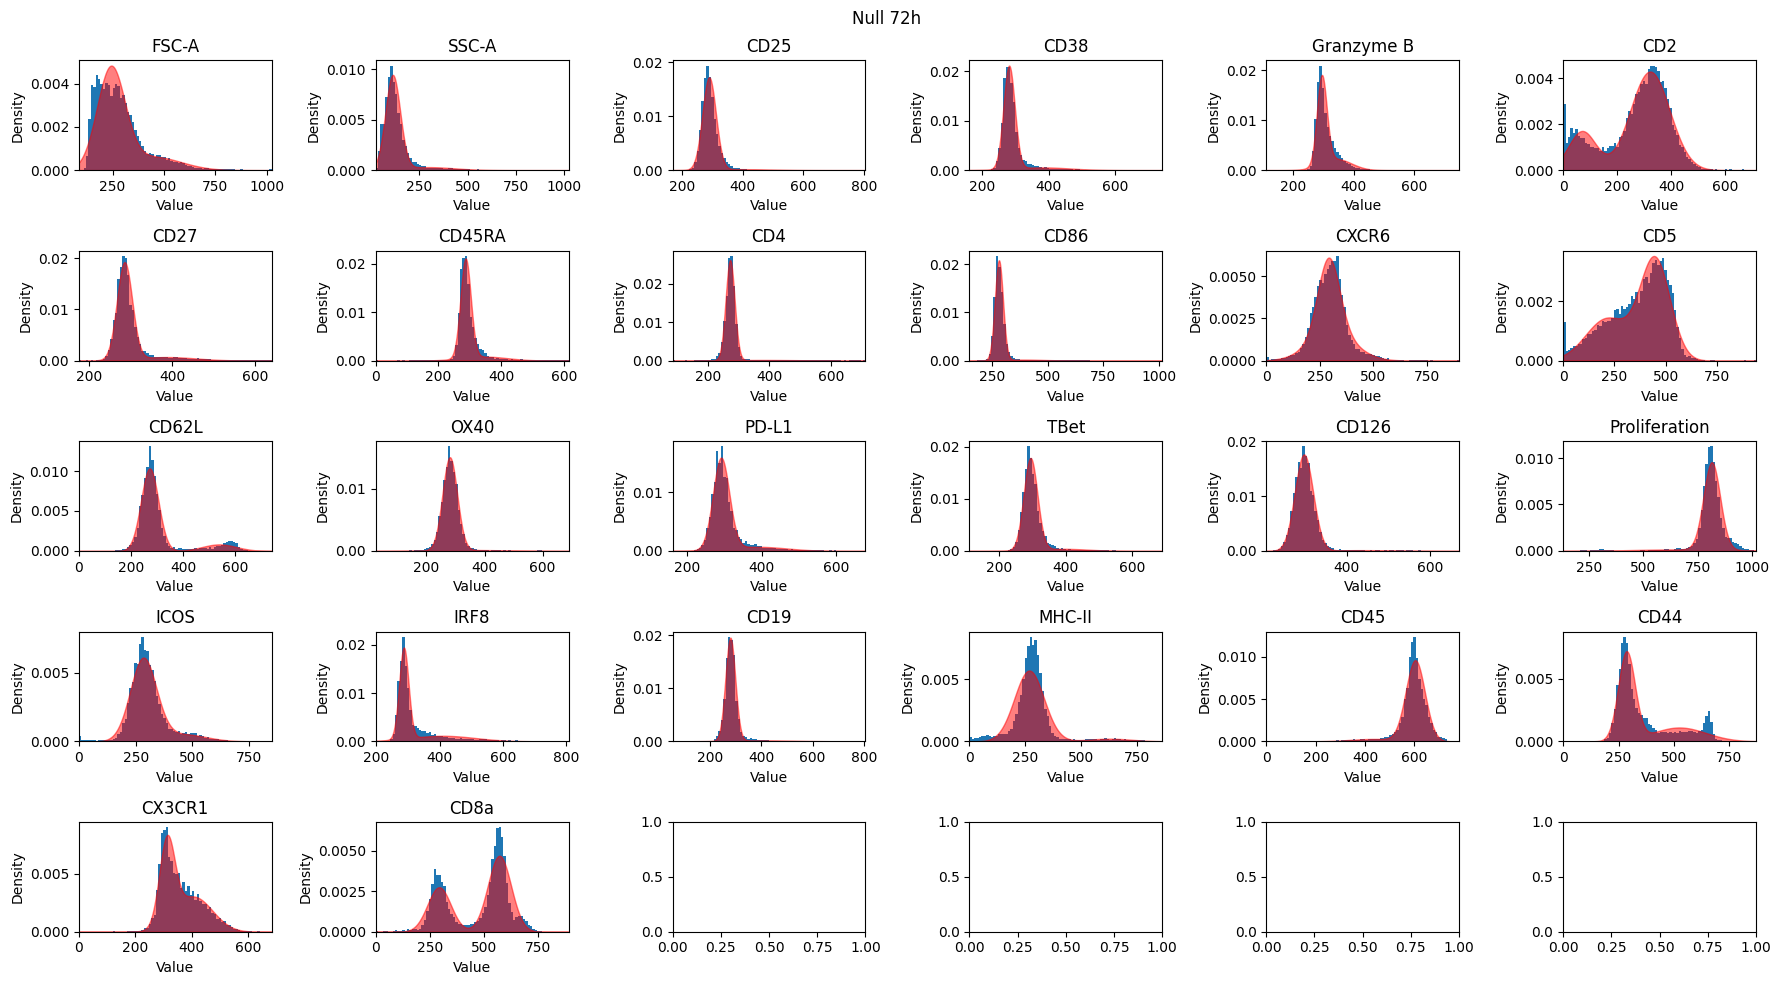

In [83]:
data_filters = {
    'CellType': 'OT-1',
    'Time':4,
    'Peptide':'null',
    'Concentration': '1uM',
}
null_data = get_subset_data(data, data_filters)
null_t4_fits = extract_gaussian_fits(null_data.to_numpy(),'Null 4h',null_data.columns)
data_filters = {
    'CellType': 'OT-1',
    'Time':72,
    'Peptide':'null',
    'Concentration': '1uM',
}
null_data = get_subset_data(data, data_filters)
null_t72_fits = extract_gaussian_fits(null_data.to_numpy(),'Null 72h',null_data.columns)

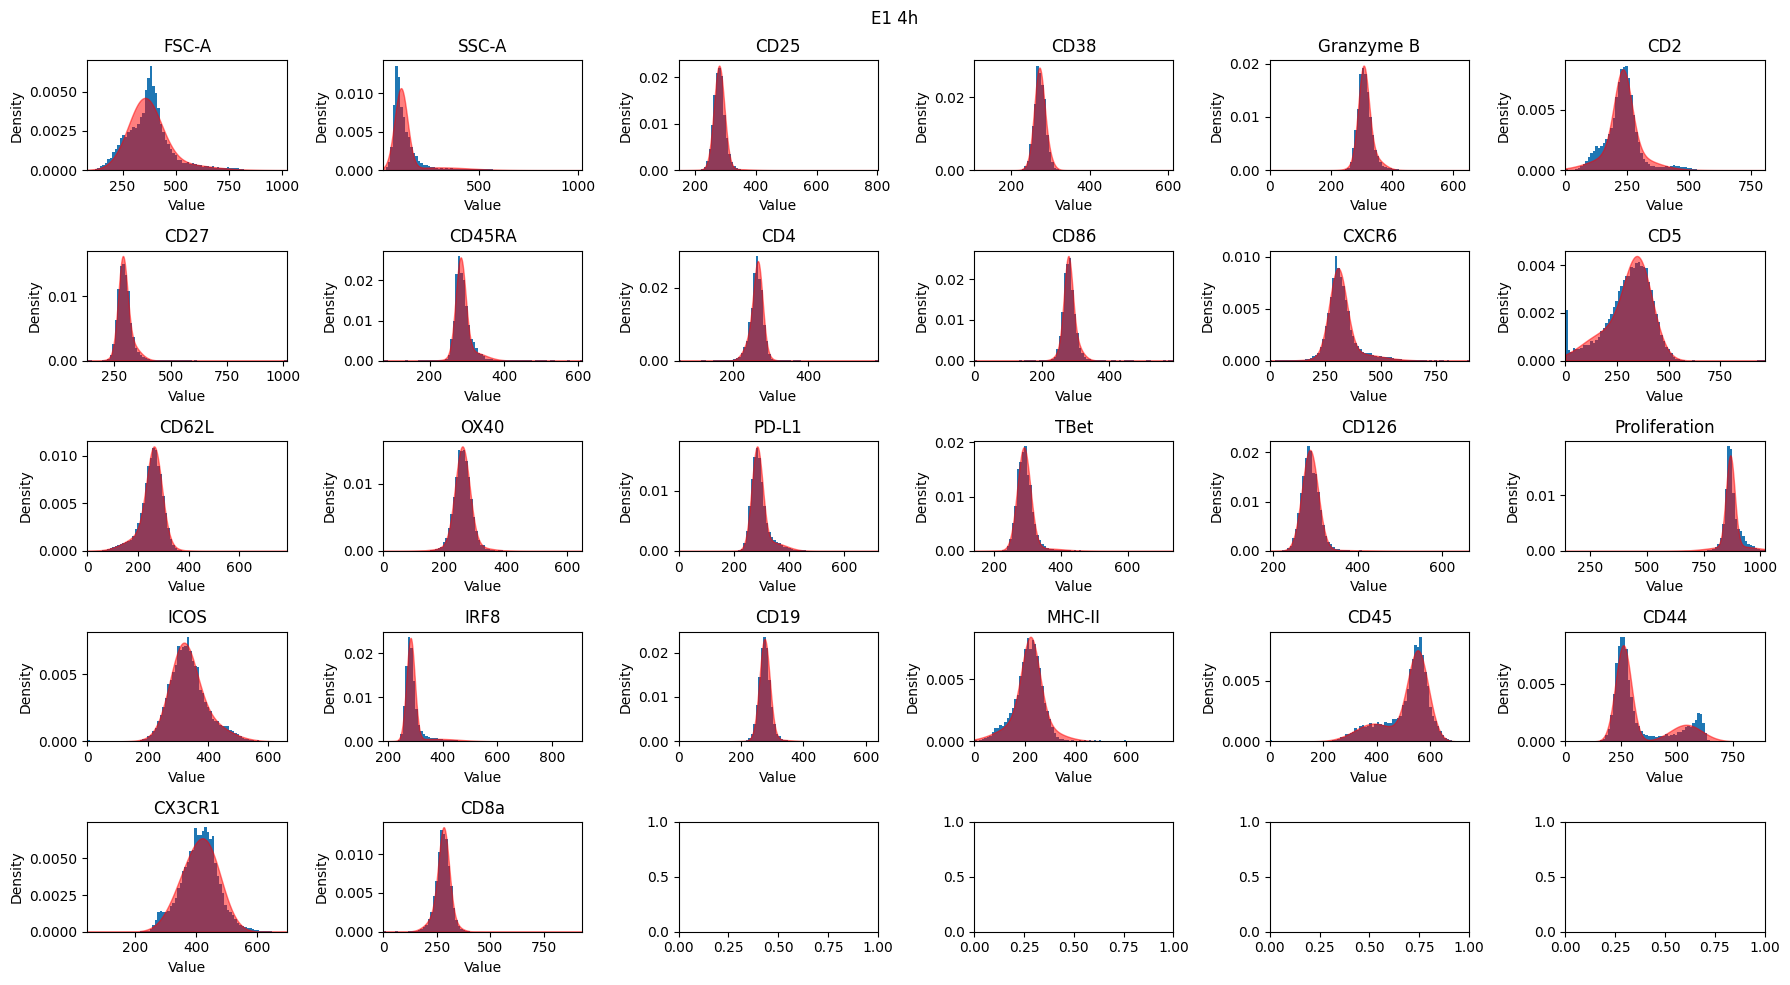

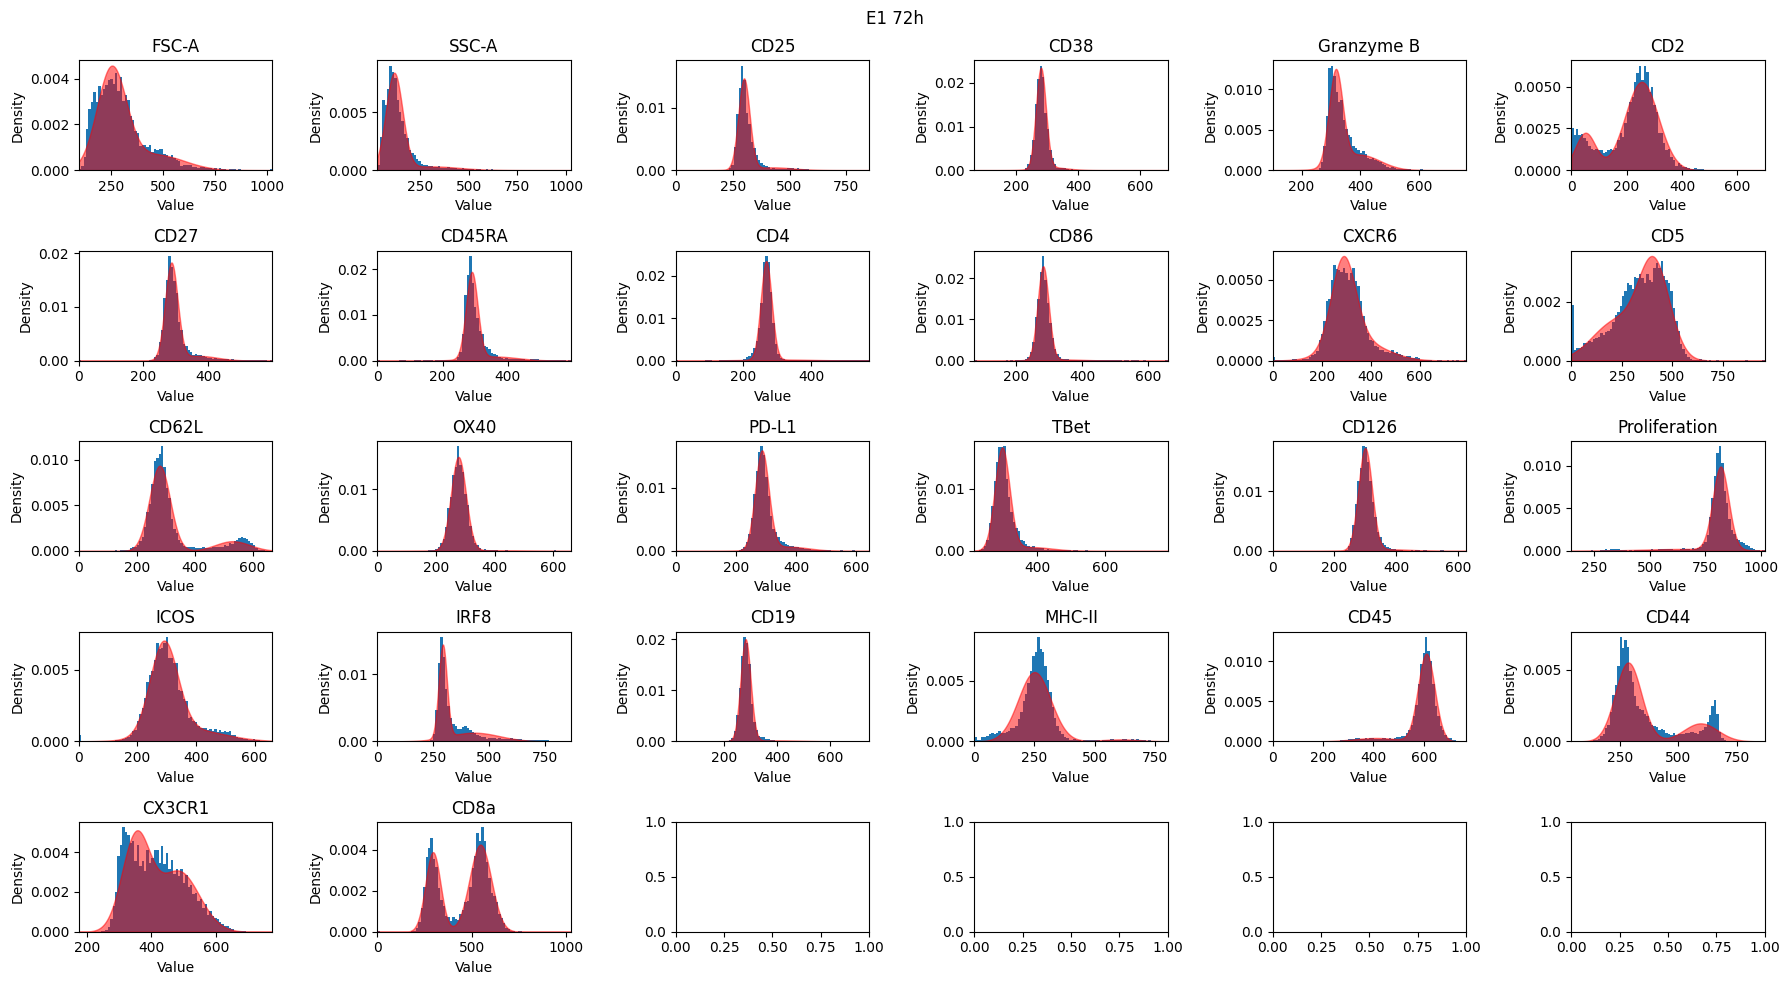

In [100]:
data_filters = {
    'CellType': 'OT-1',
    'Time':4,
    'Peptide':'E1',
    'Concentration': '1uM',
}
n4_data = get_subset_data(data, data_filters)
n4_t4_fits = extract_gaussian_fits(n4_data.to_numpy(),'E1 4h',n4_data.columns)
data_filters = {
    'CellType': 'OT-1',
    'Time':72,
    'Peptide':'E1',
    'Concentration': '1uM',
}
n4_data = get_subset_data(data, data_filters)
n4_t72_fits = extract_gaussian_fits(n4_data.to_numpy(),'E1 72h',n4_data.columns)

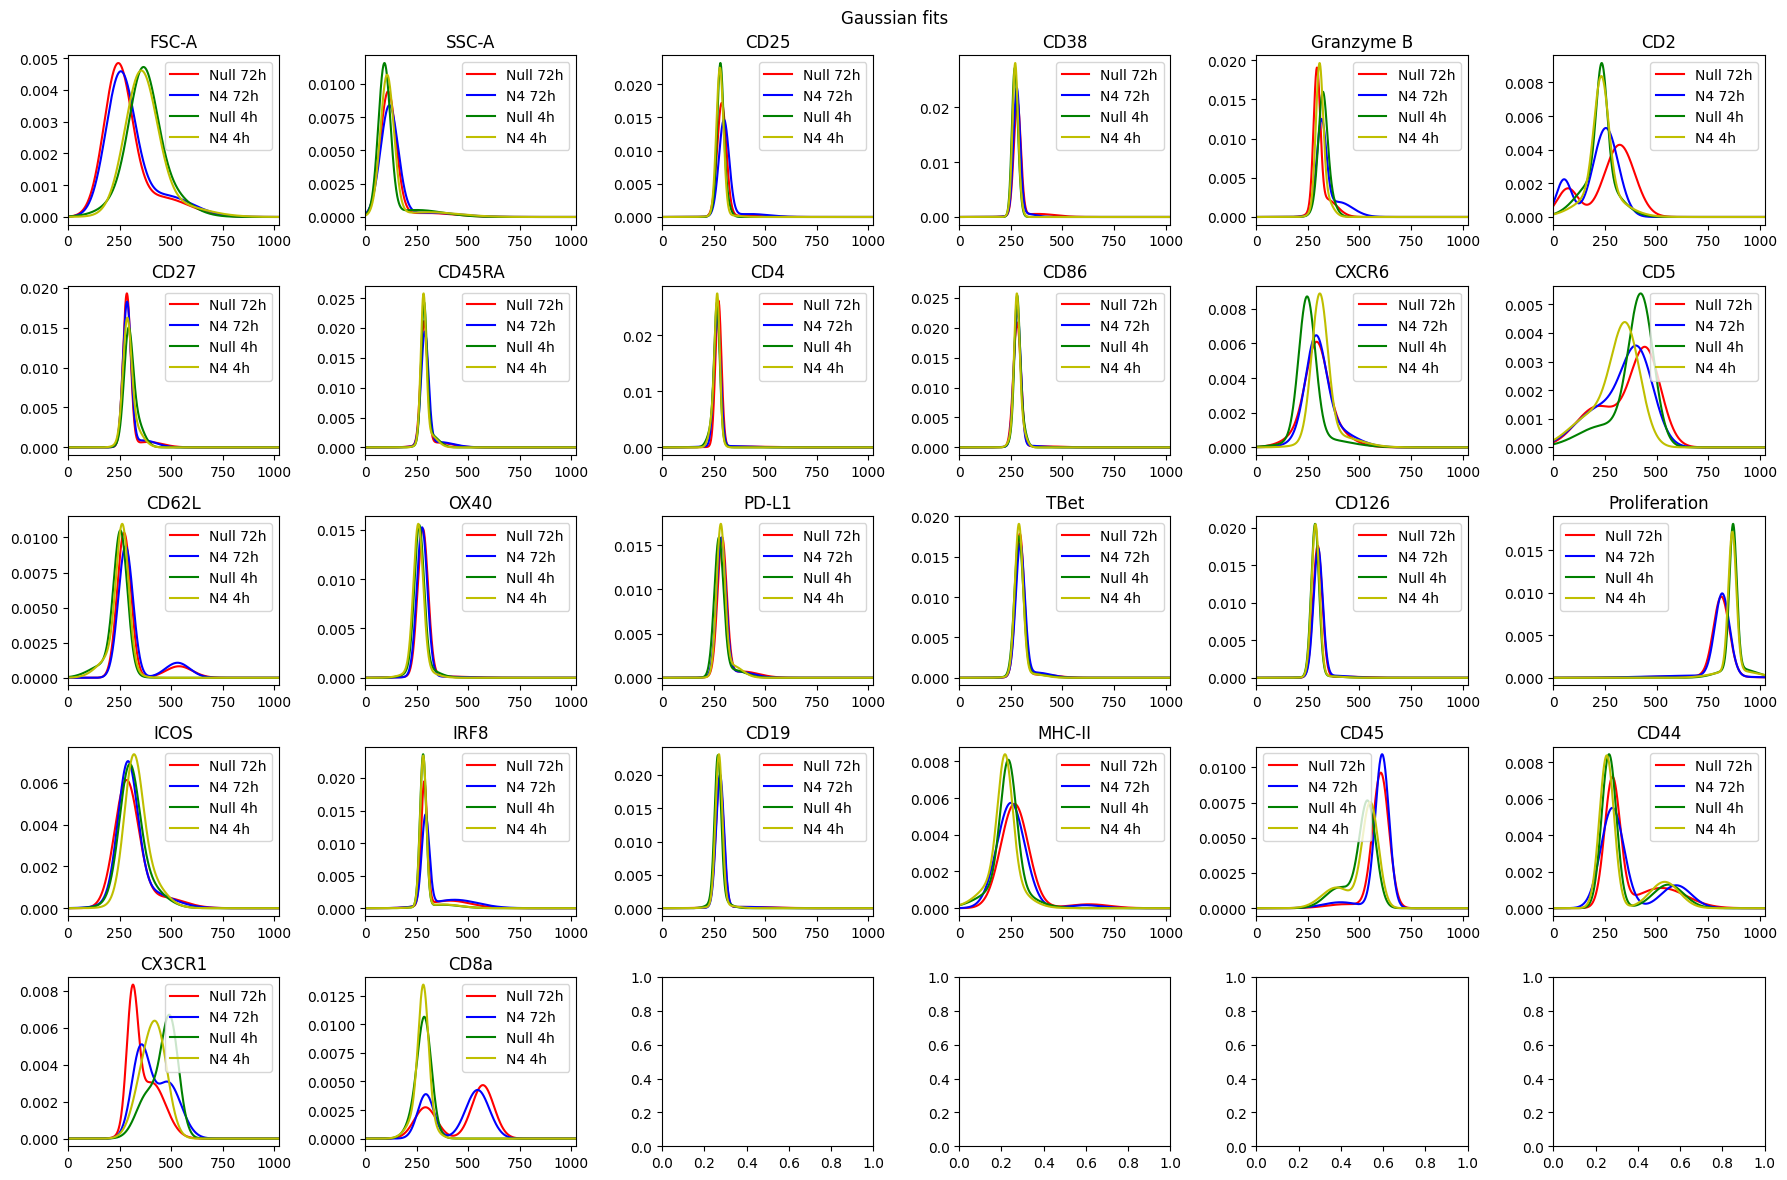

In [99]:
#plot the gaussian fits all together (null_t72_fits, n4_t72_fits, null_t4_fits, n4_t4_fits) over the same data

fig, axs = plt.subplots(5, 6, figsize=(18, 2*6))  # Adjust the number of columns per row as needed


for i in range(len(null_t72_fits)):
    ax = axs[i//6, i%6]

    x = np.linspace(0, 1024, 1000)
    logprob = null_t72_fits[i].score_samples(x.reshape(-1, 1))
    pdf = np.exp(logprob)
    ax.plot(x, pdf, color='r')
    logprob = n4_t72_fits[i].score_samples(x.reshape(-1, 1))
    pdf = np.exp(logprob)
    ax.plot(x, pdf, color='b')
    logprob = null_t4_fits[i].score_samples(x.reshape(-1, 1))
    pdf = np.exp(logprob)
    ax.plot(x, pdf, color='g')
    logprob = n4_t4_fits[i].score_samples(x.reshape(-1, 1))
    pdf = np.exp(logprob)
    ax.plot(x, pdf, color='y')
    ax.set_xlim(0,1024)
    ax.set_title(f'{null_data.columns[i]}')
    ax.legend(['Null 72h', 'E1 72h', 'Null 4h', 'E1 4h'])  # Add legend

plt.suptitle('Gaussian fits')
plt.tight_layout()
plt.show()